In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from src.data_reading import parse_galaxy_data
from src.data_treatment_tools import add_radian_columns, new_CoM_procedure 
from src.data_display import    (display_hubble_MW, 
                                display_velocities_distance, 
                                display_velocities_distance_color, 
                                animated_velocities_distance,
                                display_mean_squared_velocity,
                                display_velocities_distance_hubble_regression,
                                display_mean_squared_velocity_consistent
                                )
from IPython.display import clear_output
import matplotlib as mpl
import pypolychord
from pypolychord.settings import PolyChordSettings
from pypolychord.priors import UniformPrior
from getdist import plots, MCSamples

In [2]:
mpl.rcParams['font.size'] = 12  # Taille générale
mpl.rcParams['axes.titlesize'] = 16  # Taille des titres des graphiques
mpl.rcParams['axes.labelsize'] = 14  # Taille des labels des axes
mpl.rcParams['xtick.labelsize'] = 12  # Taille des étiquettes de l'axe x
mpl.rcParams['ytick.labelsize'] = 12  # Taille des étiquettes de l'axe y
mpl.rcParams['legend.fontsize'] = 12  # Taille de la légende
mpl.rcParams['figure.titlesize'] = 18  # Taille du titre de la figure

In [3]:
file_path = 'data/new_data.csv'
galaxy_df = pd.read_csv(file_path)
add_radian_columns(galaxy_df)

In [4]:
galaxy1="NGC5128_CenA"
galaxy2="NGC5236_M83"
r=0.76
CoM_Name="CoM_CenA_M83_0.76"
row_name=CoM_Name
new_CoM_procedure(galaxy_df,galaxy1,galaxy2,r,row_name=CoM_Name,grid_incertainty=True)
print(galaxy_df.columns)
galaxy_df.to_csv("data/data_"+CoM_Name+".csv")

CoM_CenA_M83_0.76
Index(['Name', 'PGC', 'RA', 'Dec', 'Dis', 'e_Dis_min', 'e_Dis_max', 'ref_dis',
       'V_h', 'e_V_h', 'ref_V_h', 'Source', 'Type', 'RA_radians',
       'Dec_radians', 'cos_theta_CoM_CenA_M83_0.76',
       'angular_distance_CoM_CenA_M83_0.76', 'dis_center_CoM_CenA_M83_0.76',
       'e_dis_center_min_CoM_CenA_M83_0.76',
       'e_dis_center_max_CoM_CenA_M83_0.76',
       'major_infall_velocity_CoM_CenA_M83_0.76',
       'e_major_infall_velocity_min_CoM_CenA_M83_0.76',
       'e_major_infall_velocity_max_CoM_CenA_M83_0.76',
       'minor_infall_velocity_CoM_CenA_M83_0.76',
       'e_minor_infall_velocity_min_CoM_CenA_M83_0.76',
       'e_minor_infall_velocity_max_CoM_CenA_M83_0.76'],
      dtype='object')


In [5]:
file_path = 'data/data_'+CoM_Name+'_lg.csv'
galaxy_df = pd.read_csv(file_path)

In [6]:
df=galaxy_df
mask = ~df['Name'].str.startswith('CoM_')
G = 4.3009e-9  # Constante gravitationnelle en (km/s)² Mpc / M☉

# Minor Infall

In [7]:
def velocity_model_1(r, H0, M):
    Omega_Lambda = 0.67

    # Avoid numerical issues with the square root
    if M <= 0:
        return np.full_like(r, np.nan)  # avoid sqrt of negative mass
    
    term1 = H0 * (1.1 + 0.31 * Omega_Lambda) * r
    
    # Check if the term inside sqrt will be negative
    sqrt_term = G * M / r
    valid_points = sqrt_term > 0
    
    result = np.full_like(r, np.nan)
    if np.any(valid_points):
        result[valid_points] = term1[valid_points] - 1.1 * np.sqrt(sqrt_term[valid_points])
        
    return result

In [8]:
def velocity_model_2(r, H0, M):
    G = 6.67430e-11  # constante gravitationnelle en m^3 kg^-1 s^-2
    n = 0.702

    r = np.array(r, dtype=np.float64)

    # Éviter les divisions par zéro ou racines de valeurs négatives
    r_safe = np.where(r == 0, np.nan, r)

    # Terme 1 : - (0.940 * H0 / R^n) * (GM / H0^2)^((n+1)/3)
    factor1 = -0.940 * H0 / np.power(r_safe, n)
    factor2 = np.power((G * M) / (H0 ** 2), (n + 1) / 3)

    term1 = factor1 * factor2

    # Terme 2 : + 1.335 * H0 * R
    term2 = 1.335 * H0 * r

    # Vitesse totale
    v = term1 + term2

    return v

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypolychord
from pypolychord.settings import PolyChordSettings
from pypolychord.priors import UniformPrior
from getdist import plots, MCSamples

def analyze_velocity_model_polychord(df, mask, velocity, row_name, velocity_model, 
                                   xmin=0.5, xmax=5, plot=True, H0_prior=False, M_prior=False,
                                   add_intrinsic_scatter=True, verbose=True):
    """
    Analyze velocity model using PyPolyChord instead of emcee.
    
    Parameters:
    -----------
    df : DataFrame
        Input data
    mask : array-like
        Boolean mask for data selection
    velocity : str
        Velocity column name prefix
    row_name : str
        Row identifier suffix
    velocity_model : function
        Model function that takes (r, H0, M) and returns velocity
    xmin, xmax : float
        Distance range for fitting
    plot : bool
        Whether to create plots
    H0_prior, M_prior : bool
        Whether to use informative priors
    add_intrinsic_scatter : bool
        Whether to add intrinsic scatter to account for model inadequacy
    verbose : bool
        Whether to print diagnostic information
    
    Returns:
    --------
    H0_median, H0_uncertainty, M_median, M_uncertainty, samples
    """
    
    # -------------------
    # 1. Data preparation
    # -------------------
    df_clean = df.loc[mask, [
        'dis_center_' + row_name,
        velocity + '_' + row_name,
        'e_dis_center_min_' + row_name,
        'e_dis_center_max_' + row_name,
        'e_'+velocity+'_min_' + row_name,
        'e_'+velocity+'_max_' + row_name
    ]].apply(pd.to_numeric, errors='coerce').dropna()

    x = df_clean['dis_center_' + row_name].values
    y = df_clean[velocity+'_' + row_name].values

    xerr_low_full = df_clean['e_dis_center_min_' + row_name].values
    xerr_high_full = df_clean['e_dis_center_max_' + row_name].values
    yerr_low_full = df_clean['e_'+velocity+'_min_' + row_name].values
    yerr_high_full = df_clean['e_'+velocity+'_max_' + row_name].values

    # Apply the distance and velocity mask
    mask_fit = (x >= xmin) & (x <= xmax) & (np.absolute(y-x*70) < 400)
    x = x[mask_fit]
    y = y[mask_fit]
    xerr_low = xerr_low_full[mask_fit]
    xerr_high = xerr_high_full[mask_fit]
    yerr_low = yerr_low_full[mask_fit]
    yerr_high = yerr_high_full[mask_fit]
    
    # Calculate symmetrized errors
    xerr_sym = (xerr_low + xerr_high) / 2
    yerr_sym = (yerr_low + yerr_high) / 2
    
    # Diagnostic information
    if verbose:
        print(f"Data diagnostics:")
        print(f"  Number of data points: {len(x)}")
        print(f"  Distance range: {x.min():.2f} - {x.max():.2f} Mpc")
        print(f"  Velocity range: {y.min():.1f} - {y.max():.1f} km/s")
        print(f"  Mean distance error: {xerr_sym.mean():.3f} Mpc")
        print(f"  Mean velocity error: {yerr_sym.mean():.1f} km/s")
        print(f"  Velocity scatter (std): {y.std():.1f} km/s")
        print(f"  Mean error / scatter ratio: {yerr_sym.mean() / y.std():.3f}")
        if yerr_sym.mean() / y.std() < 0.1:
            print("  WARNING: Measurement errors much smaller than data scatter!")
            print("           This may lead to underestimated parameter uncertainties.")

    # -------------------
    # 2. Define helper functions
    # -------------------
    def total_velocity_error(r, v_err, r_err, H0, M):
        """Calculate total error including propagated uncertainty from r"""
        dr = 1e-5 * r  # small relative step
        f_plus = velocity_model(r + dr, H0, M)
        f_minus = velocity_model(r - dr, H0, M)
        df_dx = (f_plus - f_minus) / (2 * dr)
        return np.sqrt(v_err**2 + (df_dx * r_err)**2)

    # -------------------
    # 3. PyPolyChord setup
    # -------------------
    nDims = 2  # H0, M
    nDerived = 0

    def likelihood(theta):
        """Likelihood function for PyPolyChord with intrinsic scatter"""
        H0, M = theta
        
        # Calculate model predictions
        try:
            model = velocity_model(x, H0, M)
            if not np.all(np.isfinite(model)):
                return -1e30, []
        except:
            return -1e30, []
        
        # Calculate total error including propagated uncertainty
        try:
            v_total_err = total_velocity_error(x, yerr_sym, xerr_sym, H0, M)
            if not np.all(np.isfinite(v_total_err)) or np.any(v_total_err <= 0):
                return -1e30, []
        except:
            return -1e30, []
        
        # Add intrinsic scatter to account for model inadequacy
        if add_intrinsic_scatter:
            # Method 1: Add constant intrinsic scatter
            # Based on the diagnostic, you have χ²_red ≈ 4.8, so need significant intrinsic scatter
            residuals = y - model
            chi2_approx = np.sum((residuals / v_total_err)**2) / len(residuals)
            
            if chi2_approx > 2:  # If χ² is too large
                # Add intrinsic scatter to bring χ² down to ~1
                intrinsic_scatter = np.sqrt(max(0, chi2_approx - 1)) * v_total_err.mean()
                intrinsic_scatter = max(intrinsic_scatter, 50.0)  # Minimum 50 km/s
                v_total_err = np.sqrt(v_total_err**2 + intrinsic_scatter**2)
            
            # Method 2: Inflate errors based on residuals (alternative approach)
            # v_total_err = np.maximum(v_total_err, np.abs(residuals) * 0.2)
            
            # Method 3: Minimum error floor
            v_total_err = np.maximum(v_total_err, 20.0)  # Minimum 20 km/s per point
        
        # Calculate log-likelihood
        logL = -0.5 * np.sum(((y - model) / v_total_err)**2 + np.log(2 * np.pi * v_total_err**2))
        
        if not np.isfinite(logL):
            return -1e30, []
            
        return logL, []

    def prior(hypercube):
        """Prior transformation from unit hypercube to parameter space"""
        theta = []
        
        if H0_prior:
            # Gaussian prior on H0: mean=73, sigma=1.0
            from scipy.stats import norm
            theta.append(norm.ppf(hypercube[0], loc=73, scale=1.0))
            # Uniform prior on M in reasonable range
            theta.append(UniformPrior(1e11, 1e14)(hypercube[1]))
            
        elif M_prior:
            # Uniform prior on H0
            theta.append(UniformPrior(30, 90)(hypercube[0]))
            # Gaussian prior on M: mean=3e12, sigma=1e12
            from scipy.stats import norm
            theta.append(norm.ppf(hypercube[1], loc=3e12, scale=1e12))
            
        else:
            # Flat priors
            theta.append(UniformPrior(30, 150)(hypercube[0]))  # H0
            theta.append(UniformPrior(1e11, 1e15)(hypercube[1]))  # M
            
        return theta

    def dumper(live, dead, logweights, logZ, logZerr):
        """Optional dumper function"""
        if len(dead) % 100 == 0:
            print(f"LogZ: {logZ:.2f} ± {logZerr:.2f}")

    # -------------------
    # 4. Run PyPolyChord
    # -------------------
    settings = PolyChordSettings(nDims, nDerived)
    settings.file_root = f'velocity_model_{row_name}'
    settings.nlive = 500  # More live points for better sampling
    settings.do_clustering = True
    settings.read_resume = False
    settings.precision_criterion = 0.001
    
    print("Running PyPolyChord...")
    output = pypolychord.run_polychord(likelihood, nDims, nDerived, settings, prior, dumper)
    
    # Create parameter names
    paramnames = [('H0', r'H_0 \,[\mathrm{km\,s^{-1}\,Mpc^{-1}}]'), 
                  ('M', r'M \,[\mathrm{kg}]')]
    output.make_paramnames_files(paramnames)
    
    # Get posterior samples
    posterior = output.posterior
    samples = posterior.samples[:, :2]  # Only the two parameters
    
    # Calculate medians and uncertainties
    H0_median = np.median(samples[:, 0])
    M_median = np.median(samples[:, 1])
    
    H0_lower = np.percentile(samples[:, 0], 16)
    H0_upper = np.percentile(samples[:, 0], 84)
    M_lower = np.percentile(samples[:, 1], 16)
    M_upper = np.percentile(samples[:, 1], 84)
    
    H0_uncertainty = 0.5 * (H0_upper - H0_lower)
    M_uncertainty = 0.5 * (M_upper - M_lower)
    
    print(f"Results:")
    print(f"H0 = {H0_median:.1f} ± {H0_uncertainty:.1f} km/s/Mpc")
    print(f"M = ({M_median/1e12:.2f} ± {M_uncertainty/1e12:.2f}) × 10^12 kg")
    print(f"Log Evidence: {output.logZ:.2f} ± {output.logZerr:.2f}")
    
    # -------------------
    # 5. Plotting
    # -------------------
    if plot:
        # Create GetDist MCSamples object
        names = ['H0', 'M']
        labels = [r'H_0', r'M \,[kg]']
        gdsamples = MCSamples(samples=samples, names=names, labels=labels)
        
        # Triangle plot
        g = plots.get_subplot_plotter()
        g.triangle_plot(gdsamples, filled=True)
        plt.show()
        
        # -------------------
        # 6. Plot best-fit model
        # -------------------
        # Fine grid for plotting
        r_plot = np.linspace(xmin, 15, 500)
        v_median = velocity_model(r_plot, H0_median, M_median)
        
        # Sample posterior draws for uncertainty band
        n_samples = min(1000, len(samples))
        sample_indices = np.random.choice(len(samples), n_samples, replace=False)
        v_samples = np.array([velocity_model(r_plot, samples[i, 0], samples[i, 1]) 
                             for i in sample_indices])
        
        v_lower = np.percentile(v_samples, 0.15, axis=0)
        v_upper = np.percentile(v_samples, 99.85, axis=0)
        
        # Create the plot
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.errorbar(x, y, xerr=[xerr_low, xerr_high], yerr=[yerr_low, yerr_high],
                    fmt='o', color='black', ecolor='red', capsize=5, label='Data')
        
        ax.plot(r_plot, v_median, 'r-', color='blue',
                label=(rf"Fit: $H_0 = {H0_median:.1f} \pm {H0_uncertainty:.1f}$" + "\n" + 
                       rf"$M = ({M_median/1e12:.2f} \pm {M_uncertainty/1e12:.2f}) \times 10^{{12}}\, M_\odot$"))
        ax.fill_between(r_plot, v_lower, v_upper, color='blue', alpha=0.3, 
                       label=rf"$3\sigma$ credible interval")
        
        ax.set_xlabel("Distance from CoM (Mpc)")
        ax.set_ylabel(r"$v_r$ (km/s)")
        ax.grid(True)
        ax.set_xlim(0, 15)
        ax.set_ylim(-300, 1000)
        ax.legend()
        plt.show()
        
        return H0_median, H0_uncertainty, M_median, M_uncertainty, samples
    else:
        return H0_median, H0_uncertainty, M_median, M_uncertainty, samples

def diagnose_error_budget(df, mask, velocity, row_name, velocity_model, H0_guess=70, M_guess=1e12, xmin=1, xmax=15):
    """
    Diagnostic function to analyze error budget and check if parameter uncertainties are reasonable.
    """
    # Prepare data (same as main function)
    df_clean = df.loc[mask, [
        'dis_center_' + row_name,
        velocity + '_' + row_name,
        'e_dis_center_min_' + row_name,
        'e_dis_center_max_' + row_name,
        'e_'+velocity+'_min_' + row_name,
        'e_'+velocity+'_max_' + row_name
    ]].apply(pd.to_numeric, errors='coerce').dropna()

    x = df_clean['dis_center_' + row_name].values
    y = df_clean[velocity+'_' + row_name].values
    xerr_low_full = df_clean['e_dis_center_min_' + row_name].values
    xerr_high_full = df_clean['e_dis_center_max_' + row_name].values
    yerr_low_full = df_clean['e_'+velocity+'_min_' + row_name].values
    yerr_high_full = df_clean['e_'+velocity+'_max_' + row_name].values

    mask_fit = (x >= xmin) & (x <= xmax) & (np.absolute(y-x*70) < 400)
    x = x[mask_fit]
    y = y[mask_fit]
    xerr_low = xerr_low_full[mask_fit]
    xerr_high = xerr_high_full[mask_fit]
    yerr_low = yerr_low_full[mask_fit]
    yerr_high = yerr_high_full[mask_fit]
    
    xerr_sym = (xerr_low + xerr_high) / 2
    yerr_sym = (yerr_low + yerr_high) / 2
    
    # Calculate model prediction with guess parameters
    model_guess = velocity_model(x, H0_guess, M_guess)
    residuals = y - model_guess
    
    # Error budget analysis
    def total_velocity_error(r, v_err, r_err, H0, M):
        dr = 1e-5 * r
        f_plus = velocity_model(r + dr, H0, M)
        f_minus = velocity_model(r - dr, H0, M)
        df_dx = (f_plus - f_minus) / (2 * dr)
        return np.sqrt(v_err**2 + (df_dx * r_err)**2)
    
    v_err_direct = yerr_sym
    v_err_distance_only = total_velocity_error(x, np.zeros_like(yerr_sym), xerr_sym, H0_guess, M_guess)
    v_err_total = total_velocity_error(x, yerr_sym, xerr_sym, H0_guess, M_guess)
    
    # Calculate distance contribution more carefully
    v_err_from_distance = np.sqrt(np.maximum(0, v_err_total**2 - v_err_direct**2))
    
    print("ERROR BUDGET ANALYSIS")
    print("=" * 50)
    print(f"Number of data points: {len(x)}")
    print(f"Residual RMS (data - model): {np.std(residuals):.1f} km/s")
    print(f"Mean measurement error (velocity): {v_err_direct.mean():.1f} km/s")
    print(f"Mean error from distance only: {v_err_distance_only.mean():.1f} km/s")
    print(f"Mean distance contribution to total: {v_err_from_distance.mean():.1f} km/s")
    print(f"Mean total error: {v_err_total.mean():.1f} km/s")
    print(f"Ratio of residual RMS to total error: {np.std(residuals) / v_err_total.mean():.2f}")
    print(f"Chi-squared per DOF (approximate): {np.sum((residuals/v_err_total)**2) / (len(x)-2):.2f}")
    print("\nPOTENTIAL ISSUES:")
    if np.std(residuals) > 3 * v_err_total.mean():
        print("⚠️  Large residuals suggest model inadequacy or underestimated errors")
        print("   Consider adding intrinsic scatter term")
    if v_err_direct.mean() < 0.1 * np.std(y):
        print("⚠️  Measurement errors very small compared to data scatter")
        print("   This may lead to unrealistically tight parameter constraints")
    if np.any(v_err_total < 10):
        print("⚠️  Some total errors are very small (< 10 km/s)")
        print("   Consider minimum error floor")
    
    chi2_reduced = np.sum((residuals/v_err_total)**2) / (len(x)-2)
    if chi2_reduced > 3:
        print(f"⚠️  Very large reduced χ² = {chi2_reduced:.1f} >> 1")
        print("   Model is inadequate or errors severely underestimated")
        print(f"   Suggested intrinsic scatter: {np.sqrt(chi2_reduced - 1) * v_err_total.mean():.1f} km/s")
    
    # Create diagnostic plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Data vs model
    ax1.errorbar(x, y, xerr=[xerr_low, xerr_high], yerr=[yerr_low, yerr_high],
                fmt='o', color='black', ecolor='red', capsize=3, alpha=0.7)
    ax1.plot(x, model_guess, 'b-', label=f'Model (H₀={H0_guess}, M={M_guess/1e12:.1f}×10¹²)')
    ax1.set_xlabel('Distance (Mpc)')
    ax1.set_ylabel('Velocity (km/s)')
    ax1.legend()
    ax1.grid(True)
    ax1.set_title('Data vs Model')
    
    # Plot 2: Error budget
    ax2.scatter(x, v_err_direct, label='Direct velocity errors', alpha=0.7, s=20)
    ax2.scatter(x, v_err_distance_only, label='Distance errors only', alpha=0.7, s=20)
    ax2.scatter(x, v_err_total, label='Total errors', alpha=0.7, s=20)
    ax2.scatter(x, np.abs(residuals), label='|Residuals|', alpha=0.5, s=15)
    ax2.axhline(np.std(residuals), color='red', linestyle='--', 
               label=f'Residual RMS ({np.std(residuals):.1f})')
    ax2.set_xlabel('Distance (Mpc)')
    ax2.set_ylabel('Error (km/s)')
    ax2.set_yscale('log')
    ax2.legend()
    ax2.grid(True)
    ax2.set_title('Error Budget')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'residual_rms': np.std(residuals),
        'mean_vel_error': v_err_direct.mean(),
        'mean_dist_error_contribution': v_err_from_distance.mean(),
        'mean_total_error': v_err_total.mean(),
        'error_ratio': np.std(residuals) / v_err_total.mean()
    }


In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_model_fitted(velocity,velocity_model,mask,H0,H0_sigma,M,M_sigma):
    def velocity_model(r, H0, M):
        Omega_Lambda = 0.67
        term1 = H0 * (1.1 + 0.31 * Omega_Lambda) * r
        term2 = 1.1 * np.sqrt(G * M / r)  
        return term1 - term2

    # === DISTANCES POUR COURBE THÉORIQUE ===
    r = np.linspace(0.5, 15, 300)
    v_r = velocity_model(r, H0, M)

    # Vitesse min/max pour zone d'incertitude
    v_r_min = velocity_model(r, H0 - H0_sigma, M - M_sigma)
    v_r_max = velocity_model(r, H0 + H0_sigma, M + M_sigma)

    # === EXTRACTION DES DONNÉES ===
    x = pd.to_numeric(df.loc[mask, 'dis_center_' + row_name], errors='coerce').values
    y = pd.to_numeric(df.loc[mask, velocity+"_" + row_name], errors='coerce').values
    names = df.loc[mask, 'Name'].astype(str).values  # Nom des galaxies

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # === ERREURS SUR DONNÉES ===
    col_e_x_max = 'e_dis_center_max_' + row_name
    col_e_x_min = 'e_dis_center_min_' + row_name
    col_e_y_max = 'e_'+velocity+'_max_' + row_name
    col_e_y_min = 'e_'+velocity+'_min_' + row_name

    if all(col in df.columns for col in [col_e_x_max, col_e_x_min, col_e_y_max, col_e_y_min]):
        e_x_min = pd.to_numeric(df.loc[mask, col_e_x_min], errors='coerce').values
        e_x_max = pd.to_numeric(df.loc[mask, col_e_x_max], errors='coerce').values
        e_y_min = pd.to_numeric(df.loc[mask, col_e_y_min], errors='coerce').values
        e_y_max = pd.to_numeric(df.loc[mask, col_e_y_max], errors='coerce').values

        # === TRAITEMENT DES GALAXIES SPECIALES ===
        special_mask = np.array(["cena" in name.lower() or "M83" in name.upper() for name in names])
        normal_mask = ~special_mask

        # Galaxies normales : ronds
        ax.errorbar(
            x[normal_mask], y[normal_mask],
            xerr=[e_x_min[normal_mask], e_x_max[normal_mask]],
            yerr=[e_y_min[normal_mask], e_y_max[normal_mask]],
            fmt='o', color='black', capsize=5, ecolor='red', label="Data"
        )

        # Galaxies spéciales : étoiles
        ax.errorbar(
            x[special_mask], y[special_mask],
            xerr=[e_x_min[special_mask], e_x_max[special_mask]],
            yerr=[e_y_min[special_mask], e_y_max[special_mask]],
            fmt='*', color='orange', capsize=5, ecolor='orange', markersize=20, label="CenA / M83"
        )

    # === COURBE THÉORIQUE + INCERTITUDE ===
    ax.plot(r, v_r, label=rf"Fit: $H_0 = {H0:.1f} \pm {H0_sigma:.1f}$"+ "\n"+ rf"$M = ({M/1e12:.2f} \pm {M_sigma/1e12:.2f}) \times 10^{{12}}\, M_\odot$", color='green')
    ax.fill_between(r, v_r_min, v_r_max, color='green', alpha=0.3, label="uncertainties")

    # === MISE EN FORME ===
    ax.set_xlabel("Distance from CoM (Mpc)")
    ax.set_ylabel(r"$v_r$ (km/s)")
    ax.set_xlim(0, 14)
    ax.set_ylim(-500, 1500)
    ax.grid(True)
    ax.legend()
    plt.show()


In [11]:
def plot_fit_max_dist(df,mask,row_name,velocity,velocity_model,xmin,xminmax,xmaxmax,Nb_point):

    # Vecteur r (de 0 à 4, 10 points)
    r_plot = np.linspace(xminmax, xmaxmax, Nb_point)

    H_values = []
    H_sigmas = []
    M_values = []
    M_sigmas = []
    # Remplissage des valeurs
    for k in r_plot:
        H0, H0_sigma, M , M_sigma, _ = analyze_velocity_model_polychord(df=df, mask=mask, row_name=row_name,velocity=velocity,velocity_model=velocity_model, xmin=xmin,xmax=k,plot= False)
        H_values.append(H0)
        H_sigmas.append(H0_sigma)
        M_values.append(M)
        M_sigmas.append(M_sigma)

    # Création de la figure
    fig, ax1 = plt.subplots()

    # Axe primaire pour H
    ax1.set_xlabel("r")
    ax1.set_ylabel("H", color="tab:blue")
    ax1.plot(r_plot, H_values, marker='o', color="tab:blue", label="H")
    ax1.fill_between(r_plot,
                     np.array(H_values) - np.array(H_sigmas),
                     np.array(H_values) + np.array(H_sigmas),
                     color="tab:blue", alpha=0.2, label="H uncertainty")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Axe secondaire pour M
    ax2 = ax1.twinx()
    ax2.set_ylabel("M", color="tab:red")
    ax2.plot(r_plot, M_values, marker='s', linestyle='--', color="tab:red", label="M")
    ax2.fill_between(r_plot,
                     np.array(M_values) - np.array(M_sigmas),
                     np.array(M_values) + np.array(M_sigmas),
                     color="tab:red", alpha=0.2, label="M uncertainty")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    # Titre et mise en page
    plt.title("Évolution de H et M en fonction de r")
    fig.tight_layout()

    # Affichage du graphique
    plt.show()

In [13]:
def plot_fit_min_dist(df,mask,row_name,velocity,velocity_model,xmax,xminmin,xmaxmin,Nb_point):

    # Vecteur r (de 0 à 4, 10 points)
    r_plot = np.linspace(xminmin, xmaxmin, Nb_point)

    H_values = []
    H_sigmas = []
    M_values = []
    M_sigmas = []
    # Remplissage des valeurs
    for k in r_plot:
        H0, H0_sigma, M , M_sigma, _ = analyze_velocity_model_polychord(df=df, mask=mask, row_name=row_name,velocity=velocity,velocity_model=velocity_model, xmin=k,xmax=xmax,plot= False)
        H_values.append(H0)
        H_sigmas.append(H0_sigma)
        M_values.append(M)
        M_sigmas.append(M_sigma)

    # Création de la figure
    fig, ax1 = plt.subplots()

    # Axe primaire pour H
    ax1.set_xlabel("r")
    ax1.set_ylabel("H", color="tab:blue")
    ax1.plot(r_plot, H_values, marker='o', color="tab:blue", label="H")
    ax1.fill_between(r_plot,
                     np.array(H_values) - np.array(H_sigmas),
                     np.array(H_values) + np.array(H_sigmas),
                     color="tab:blue", alpha=0.2, label="H uncertainty")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Axe secondaire pour M
    ax2 = ax1.twinx()
    ax2.set_ylabel("M", color="tab:red")
    ax2.plot(r_plot, M_values, marker='s', linestyle='--', color="tab:red", label="M")
    ax2.fill_between(r_plot,
                     np.array(M_values) - np.array(M_sigmas),
                     np.array(M_values) + np.array(M_sigmas),
                     color="tab:red", alpha=0.2, label="M uncertainty")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    # Titre et mise en page
    plt.title("Évolution de H et M en fonction de r")
    fig.tight_layout()

    # Affichage du graphique
    plt.show()

Data diagnostics:
  Number of data points: 68
  Distance range: 0.57 - 4.95 Mpc
  Velocity range: -141.7 - 678.0 km/s
  Mean distance error: 0.186 Mpc
  Mean velocity error: 10.5 km/s
  Velocity scatter (std): 147.8 km/s
  Mean error / scatter ratio: 0.071
           This may lead to underestimated parameter uncertainties.
Running PyPolyChord...
PolyChord: MPI is already initilised, not initialising, and will not finalize

PolyChord: Next Generation Nested Sampling
copyright: Will Handley, Mike Hobson & Anthony Lasenby
  version: 1.22.1
  release: 10th Jan 2024
    email: wh260@mrao.cam.ac.uk

Run Settings
nlive    :     500
nDims    :       2
nDerived :       0
Doing Clustering
Synchronous parallelisation
Generating equally weighted posteriors
Generating weighted posteriors
Clustering on posteriors
Writing a resume file to chains/velocity_model_CoM_CenA_M83_0.76.resume

generating live points


all live points generated

Speed  1 =  0.303E-03 seconds
number of repeats:           10
st

chains/velocity_model_CoM_CenA_M83_0.76.txt
Removed no burn in
Results:
H0 = 63.0 ± 2.8 km/s/Mpc
M = (20.42 ± 15.11) × 10^12 kg
Log Evidence: -404.70 ± 0.08
Removed no burn in


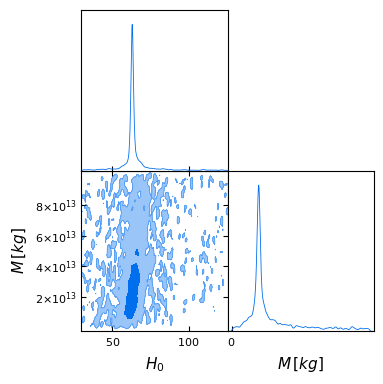

/tmp/ipykernel_15199/3108231522.py:258: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_median, 'r-', color='blue',


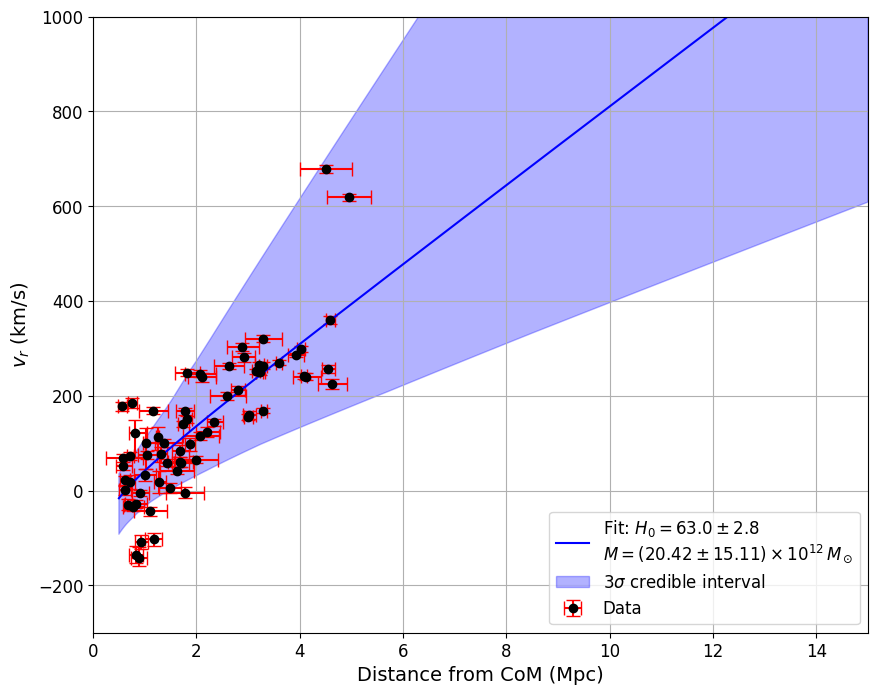

In [13]:
# # First, diagnose the error budget
# diagnostics = diagnose_error_budget(df, mask, velocity='minor_infall_velocity', row_name=row_name, velocity_model=velocity_model_1)

# Then run the analysis with intrinsic scatter
H0, H0_err, M, M_err, samples = analyze_velocity_model_polychord(
    df, mask, velocity='minor_infall_velocity', row_name=row_name, velocity_model=velocity_model_1, 
    add_intrinsic_scatter=True, verbose=True
)

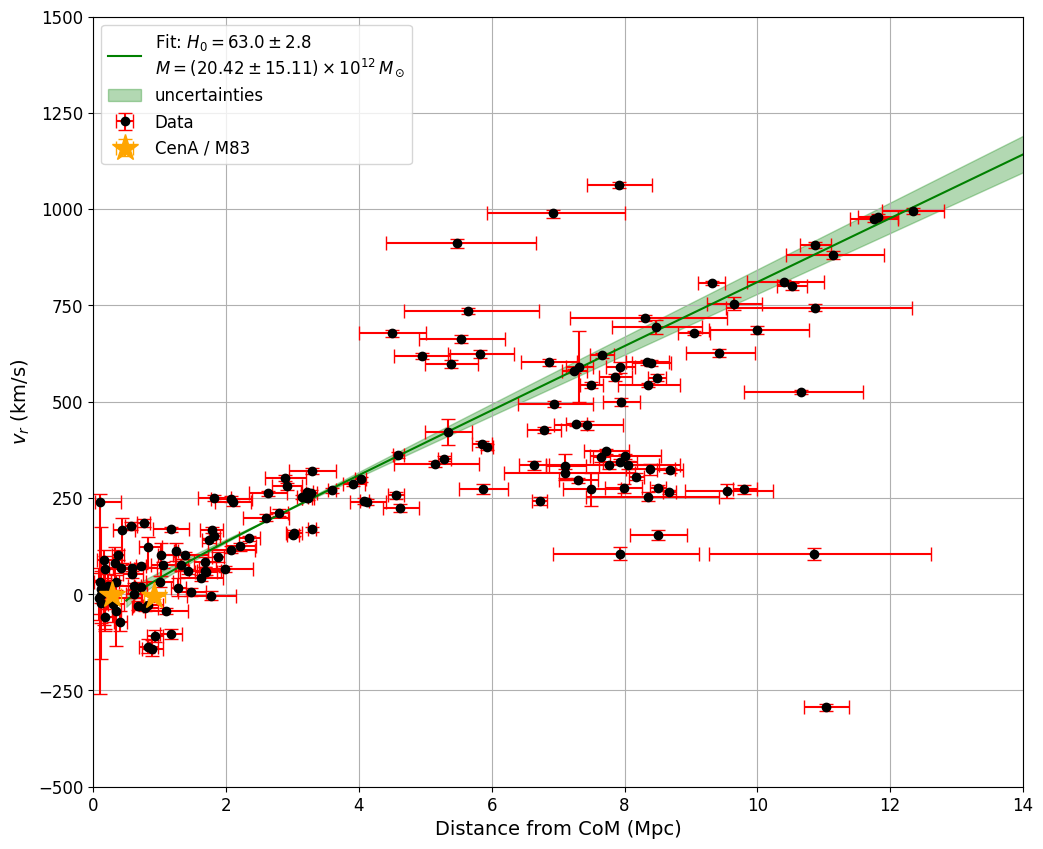

In [15]:
plot_model_fitted(velocity='minor_infall_velocity',velocity_model=velocity_model_1,mask=mask,H0=H0,H0_sigma=H0_err,M=M,M_sigma=M_err)

# Major infall

Data diagnostics:
  Number of data points: 65
  Distance range: 0.57 - 4.95 Mpc
  Velocity range: -192.9 - 712.3 km/s
  Mean distance error: 0.189 Mpc
  Mean velocity error: 149.9 km/s
  Velocity scatter (std): 170.3 km/s
  Mean error / scatter ratio: 0.880
Running PyPolyChord...
PolyChord: MPI is already initilised, not initialising, and will not finalize

PolyChord: Next Generation Nested Sampling
copyright: Will Handley, Mike Hobson & Anthony Lasenby
  version: 1.22.1
  release: 10th Jan 2024
    email: wh260@mrao.cam.ac.uk

Run Settings
nlive    :     500
nDims    :       2
nDerived :       0
Doing Clustering
Synchronous parallelisation
Generating equally weighted posteriors
Generating weighted posteriors
Clustering on posteriors
Writing a resume file to chains/velocity_model_CoM_CenA_M83_0.76.resume

generating live points


all live points generated

Speed  1 =  0.161E-03 seconds
number of repeats:           10
started sampling

_________________
lives      | 500 |
phantoms   |29

 ____________________________________________________ 
|                                                    |
| ndead  =         6465                              |
| log(Z) =         -430.17038 +/-            0.09021 |
|____________________________________________________|
chains/velocity_model_CoM_CenA_M83_0.76.txt
Removed no burn in
Results:
H0 = 66.7 ± 5.7 km/s/Mpc
M = (151.00 ± 115.46) × 10^12 kg
Log Evidence: -430.17 ± 0.09
Removed no burn in


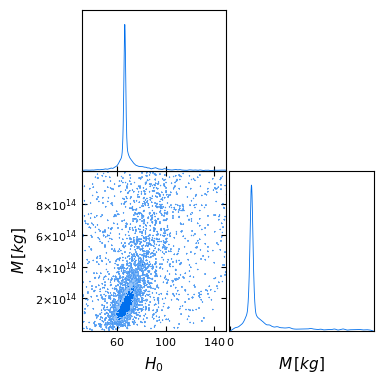

/tmp/ipykernel_15523/189257386.py:258: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_median, 'r-', color='blue',


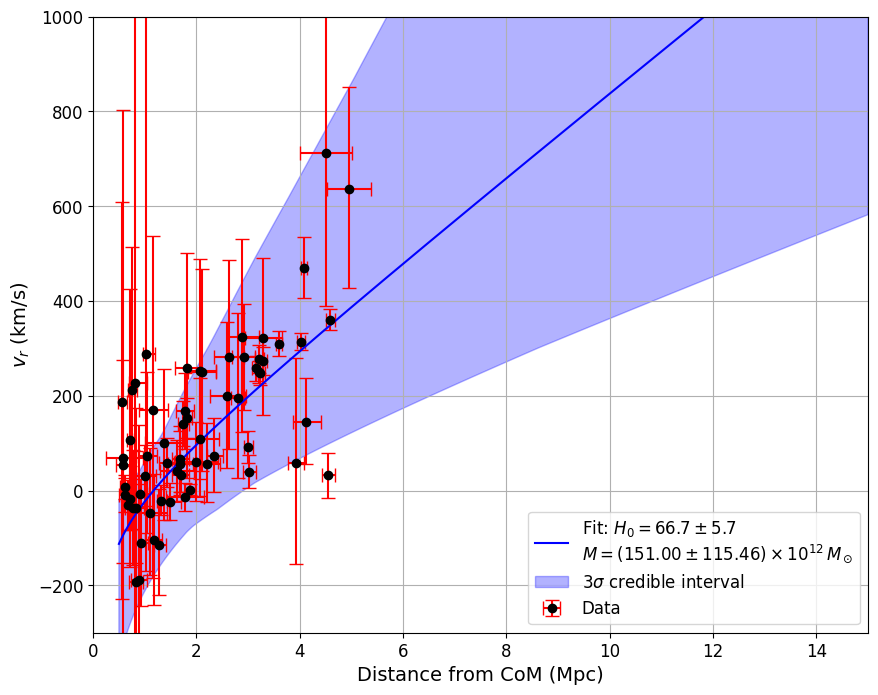

In [12]:
H0, H0_err, M, M_err, samples = analyze_velocity_model_polychord(
    df, mask, velocity='major_infall_velocity', row_name=row_name, velocity_model=velocity_model_1, 
    add_intrinsic_scatter=True, verbose=True
)

In [ ]:
plot_model_fitted(velocity='major_infall_velocity',velocity_model=velocity_model_1,mask=mask,H0=H0_maj,H0_sigma=H0_sigma_maj,M=M_maj,M_sigma=M_sigma_maj)

NameError: name 'H0_maj' is not defined

Removed no burn in
Removed no burn in


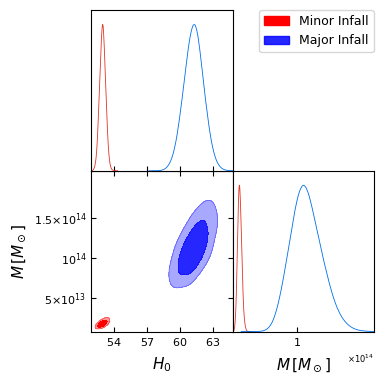

=== Résultats Minor Infall ===
H0 = 52.98 ± 0.27
M = (18.80 ± 2.88) × 10^12 M_☉

=== Résultats Major Infall ===
H0 = 61.29 ± 0.90
M = (111.20 ± 22.35) × 10^12 M_☉


In [ ]:
# Définition des noms et labels cohérents
names = ['H0', 'M']
labels = [r'H_0', r'M \,[M_\odot]']  # Utiliser M_☉ (masse solaire) pour être cohérent

# Créer les objets MCSamples pour les deux analyses
gdsamples_min = MCSamples(samples=samples_min, names=names, labels=labels)
gdsamples_maj = MCSamples(samples=samples_maj, names=names, labels=labels)

# Créer le triangle plot avec les deux distributions
g = plots.get_subplot_plotter()
g.triangle_plot([gdsamples_min, gdsamples_maj], 
                filled=True, 
                legend_labels=['Minor Infall', 'Major Infall'],
                colors=['red', 'blue'])  # Ajouter des couleurs différentes pour mieux distinguer

plt.show()

# Optionnel : afficher les résultats numériques
print("=== Résultats Minor Infall ===")
print(f"H0 = {H0_min:.2f} ± {H0_sigma_min:.2f}")
print(f"M = ({M_min/1e12:.2f} ± {M_sigma_min/1e12:.2f}) × 10^12 M_☉")

print("\n=== Résultats Major Infall ===")
print(f"H0 = {H0_maj:.2f} ± {H0_sigma_maj:.2f}")
print(f"M = ({M_maj/1e12:.2f} ± {M_sigma_maj/1e12:.2f}) × 10^12 M_☉")
plt.show()

100%|██████████| 5000/5000 [00:19<00:00, 251.40it/s]


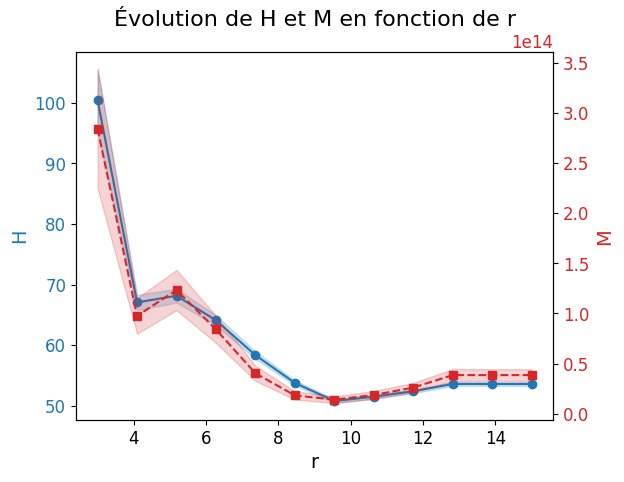

In [ ]:
plot_fit_max_dist(df=df,mask=mask,row_name=row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1,xmin=1,xminmax=3,xmaxmax=15,Nb_point=12)

100%|██████████| 5000/5000 [00:22<00:00, 226.82it/s]


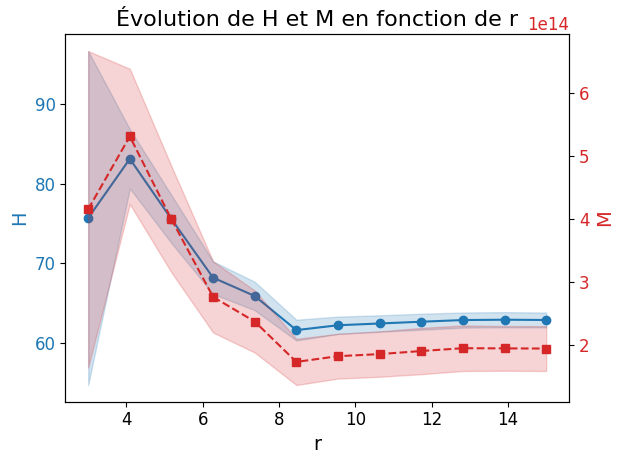

In [ ]:
plot_fit_max_dist(df=df,mask=mask,row_name=row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1,xmin=1,xminmax=3,xmaxmax=15,Nb_point=12)

100%|██████████| 5000/5000 [00:15<00:00, 330.97it/s]


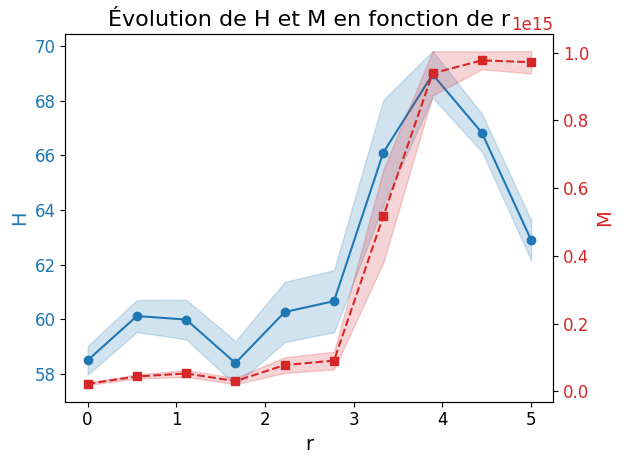

In [ ]:
plot_fit_min_dist(df=df,mask=mask,row_name=row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1,xmax=7,xminmin=0,xmaxmin=5,Nb_point=10)

 20%|██        | 1008/5000 [00:03<00:12, 321.80it/s]

100%|██████████| 5000/5000 [00:15<00:00, 324.06it/s]


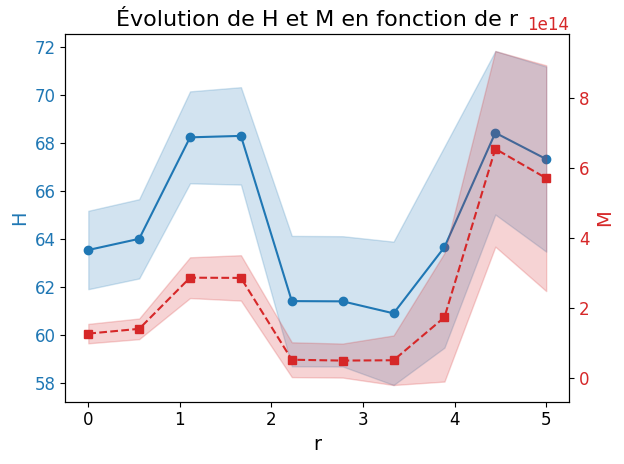

In [ ]:
plot_fit_min_dist(df=df,mask=mask,row_name=row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1,xmax=7,xminmin=0,xmaxmin=5,Nb_point=10)